AI : The first version to improve the accuracy:
- I use 50,000 rows instead of 20,000
- I switched to TF-IDF instead of CountVectorizer
- I increased SVD from 100 to 200 components
- I added 6 extra features from the URL itself
- I test different values of k using cross-validation

Import Libraries

In [1]:
import os
import re
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

Configuration
I put one dictionary at the top so I can change them easily

In [2]:
CONFIG = {
    "data_path":      "../preprocessing-dataset/processed_data.csv",
    "result_dir":     "result",
    "text_column":    "processed_text",
    "label_column":   "Label",
    "url_column":     "URL",
    "sample_size":    50000,
    "test_size":      0.2,
    "random_state":   42,
    "svd_components": 200,
    "k_candidates":   [3, 5, 7, 11],
}

os.makedirs(CONFIG["result_dir"], exist_ok=True)

Load Data
load the processed data and take a sample of 50,000 rows. I use random url to make sure the good and bad URL ratio stays the same .

In [3]:
df_full = pd.read_csv(CONFIG["data_path"])
print(f"Full dataset shape: {df_full.shape}")

df, _ = train_test_split(
    df_full,
    train_size=CONFIG["sample_size"],
    random_state=CONFIG["random_state"],
    stratify=df_full[CONFIG["label_column"]],
)
df = df.reset_index(drop=True)

print(f"Sampled dataset shape: {df.shape}")
print(f"Label distribution:\n{df[CONFIG['label_column']].value_counts()}")
df.head()

Full dataset shape: (549346, 3)
Sampled dataset shape: (50000, 3)
Label distribution:
Label
good    35763
bad     14237
Name: count, dtype: int64


,URL,Label,processed_text
0,facebook.com/pages/Edan-Everly/113900548620801,good,facebook com page edan ever 113900548620801
1,pplumbing.us/file/outlook,bad,pplumb us file outlook
2,imdb.com/name/nm0559618/,good,imdb com name nm0559618
3,142.0.78.36/adeola/server/cp.php?m=login,bad,142 0 78 36 adeola server cp php m login
4,dannykimm.com/wp-content/uploads/2012/01/absa/...,bad,dannykimm com wp content upload 2012 01 absa n...


URL Features

AI: I create 6 extra features from the raw URL before splitting the data. Things like how long the URL is, how many dots it has, and whether it contains an IP address are useful signals that the text features might miss.

In [4]:
def extract_url_features(url: str) -> list:
    """Extract 6 handcrafted features from a raw URL string.

    Args:
        url: The raw URL string.

    Returns:
        A list of 6 numeric features: url_length, num_dots, num_digits,
        num_special, has_ip, subdomain_depth.
    """
    return [
        len(url),
        url.count("."),
        sum(c.isdigit() for c in url),
        sum(c in "@-_=?&" for c in url),
        1 if re.search(r"\d+\.\d+\.\d+\.\d+", url) else 0,
        max(0, len(url.split("/")[2].split(".")) - 2) if "//" in url else 0,
    ]


url_features = np.array(
    [extract_url_features(str(u)) for u in df[CONFIG["url_column"]].fillna("")]
)
print(f"URL feature matrix shape: {url_features.shape}")
print("Features: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth")

URL feature matrix shape: (50000, 6)
Features: url_length, num_dots, num_digits, num_special, has_ip, subdomain_depth


Prepare Labels

In [5]:
y = df[CONFIG["label_column"]].values
print(f"Label array shape:  {y.shape}")
print(f"Unique labels:      {np.unique(y)}")

Label array shape:  (50000,)
Unique labels:      ['bad' 'good']


Train and Test Split
Split the data 80% for training and 20% for testing. I use random split so both test and train have the same ratio of good and bad URLs.

In [6]:
text_col = df[CONFIG["text_column"]].fillna("").astype(str).values

(
    text_train, text_test,
    url_feat_train, url_feat_test,
    y_train, y_test,
) = train_test_split(
    text_col, url_features, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y,
)

print(f"Training samples: {len(text_train)}")
print(f"Test samples:     {len(text_test)}")

Training samples: 40000
Test samples:     10000


TF-IDF Vectorization

AI : Here I convert the cleaned URL text into numbers using `TfidfVectorizer`. TF-IDF is better than just counting words because it gives less weight to very common words. I only fit the vectorizer on the training data so the test data does not affect the vocabulary.

In [7]:
tfidf = TfidfVectorizer(
    sublinear_tf=True,
    min_df=2,
    max_features=100000,
)
x_train_tfidf = tfidf.fit_transform(text_train)
x_test_tfidf  = tfidf.transform(text_test)

print(f"TF-IDF train shape: {x_train_tfidf.shape}")
print(f"TF-IDF test shape:  {x_test_tfidf.shape}")

TF-IDF train shape: (40000, 15323)
TF-IDF test shape:  (10000, 15323)


Reduce Dimensions with SVD

AI : The TF-IDF matrix has too many columns, so I use `TruncatedSVD` to reduce it to 200 dimensions. This makes KNN faster to run. I fit the SVD on training data only.

In [8]:
svd = TruncatedSVD(n_components=CONFIG["svd_components"], random_state=CONFIG["random_state"])
x_train_svd = svd.fit_transform(x_train_tfidf)
x_test_svd  = svd.transform(x_test_tfidf)

explained_var = svd.explained_variance_ratio_.sum()
print(f"Reduced feature dims: {x_train_svd.shape[1]}")
print(f"Explained variance:   {explained_var:.2%}")

Reduced feature dims: 200
Explained variance:   37.41%


Combine Features

AI : I join the 200 SVD columns and the 6 URL features together. Then I use `StandardScaler` to normalise everything because KNN uses distances and big numbers like URL length would dominate if I do not scale.

In [9]:
x_train_combined = np.hstack([x_train_svd, url_feat_train])
x_test_combined  = np.hstack([x_test_svd,  url_feat_test])

scaler = StandardScaler()
x_train_final = scaler.fit_transform(x_train_combined)
x_test_final  = scaler.transform(x_test_combined)

print(f"Combined feature shape (train): {x_train_combined.shape}")
print(f"Final scaled feature shape (train): {x_train_final.shape}")

Combined feature shape (train): (40000, 206)
Final scaled feature shape (train): (40000, 206)


Find the Best k
k = 3, 5, 7 and 11 using 3-fold cross-validation on the training set. I pick the k with the best average accuracy.

In [10]:
print("Running 3-fold CV over k candidates (may take several minutes)...\n")
cv_results = {}
for k in CONFIG["k_candidates"]:
    knn_cv = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    scores = cross_val_score(knn_cv, x_train_final, y_train, cv=3, scoring="accuracy")
    cv_results[k] = scores.mean()
    print(f"  k={k:2d}: CV accuracy = {scores.mean():.4f} ± {scores.std():.4f}")

best_k = max(cv_results, key=cv_results.get)
print(f"\nBest k: {best_k}  (CV accuracy: {cv_results[best_k]:.4f})")

Running 3-fold CV over k candidates (may take several minutes)...

  k= 3: CV accuracy = 0.9102 ± 0.0022
  k= 5: CV accuracy = 0.9076 ± 0.0022
  k= 7: CV accuracy = 0.9056 ± 0.0023
  k=11: CV accuracy = 0.9019 ± 0.0029

Best k: 3  (CV accuracy: 0.9102)


Train the Final Model
Train the final KNN model using the best k value I found which is 3

In [11]:
knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
knn.fit(x_train_final, y_train)
print(f"Final KNN trained with k={best_k}.")

Final KNN trained with k=3.


Check the Results
Check the test accuracy, print the classification report, and plot a confusion matrix.

In [12]:
y_pred   = knn.predict(x_test_final)
test_acc = accuracy_score(y_test, y_pred)

print(f"Test accuracy: {test_acc:.4f}\n")
report = classification_report(y_test, y_pred)
print(report)

Test accuracy: 0.9186

              precision    recall  f1-score   support

         bad       0.87      0.84      0.85      2847
        good       0.94      0.95      0.94      7153

    accuracy                           0.92     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.92      0.92      0.92     10000



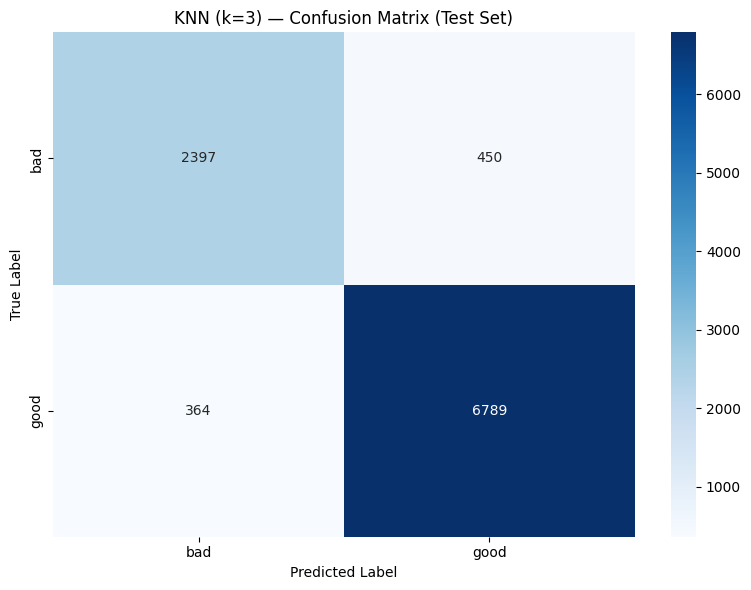

In [13]:
cm     = confusion_matrix(y_test, y_pred)
labels = sorted(np.unique(y_test))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=ax,
)
ax.set_title(f"KNN (k={best_k}) — Confusion Matrix (Test Set)")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

Save the Results
Save the trained model, the classification report, and the confusion matrix image to the result folder.

In [14]:
model_path = os.path.join(CONFIG["result_dir"], "model_knn.pkl")
with open(model_path, "wb") as f:
    pickle.dump(knn, f)
print(f"Model saved to {model_path}")

Model saved to result\model_knn.pkl


In [15]:
report_path = os.path.join(CONFIG["result_dir"], "classification_report.txt")
with open(report_path, "w") as f:
    f.write(f"Best k (3-fold CV): {best_k}\n")
    f.write(f"Test accuracy:      {test_acc:.4f}\n\n")
    f.write(report)
print(f"Classification report saved to {report_path}")

Classification report saved to result\classification_report.txt


In [16]:
cm_path = os.path.join(CONFIG["result_dir"], "confusion_matrix.png")
fig.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"Confusion matrix saved to {cm_path}")

Confusion matrix saved to result\confusion_matrix.png
